In [8]:
# Import required libraries

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from collections import Counter

In [9]:
# Load the latest version of the dataset directly into a pandas DataFrame
file_path = r"C:\Users\mail2\OneDrive\Desktop\MY_DRIVE\MLOps\MLOps-Addy\Data_Sets\Iris.csv"
dataset = pd.read_csv(file_path)
dataset.tail(10)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
140,141,6.7,3.1,5.6,2.4,Iris-virginica
141,142,6.9,3.1,5.1,2.3,Iris-virginica
142,143,5.8,2.7,5.1,1.9,Iris-virginica
143,144,6.8,3.2,5.9,2.3,Iris-virginica
144,145,6.7,3.3,5.7,2.5,Iris-virginica
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [10]:
# Basic dataset information
dataset.shape
dataset.info()
dataset.columns
dataset.describe()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [11]:
# Identify categorical, integer, and float columns
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (dataset.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (dataset.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

# Print lists of column names by data type
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()
integer_cols = dataset.select_dtypes(include=['int64']).columns.tolist()
float_cols = dataset.select_dtypes(include=['float64']).columns.tolist()
print("Categorical Columns:", categorical_cols)
print("Integer Columns:", integer_cols)
print("Float Columns:", float_cols)

Categorical variables: 1
Integer variables: 1
Float variables: 4
Categorical Columns: ['Species']
Integer Columns: ['Id']
Float Columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [12]:
# Check for missing/null values
dataset.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
# Print if any duplicates were found
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 0


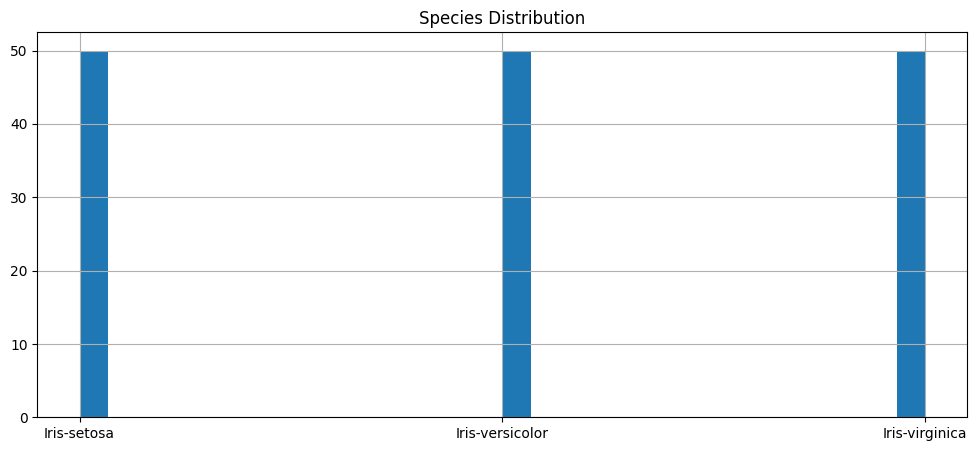

In [14]:
# Visualize the distribution of the target variable (Y) 'Species'
plt.figure(figsize=(12,5))
dataset['Species'].hist(bins=30)
plt.title("Species Distribution")
plt.show()

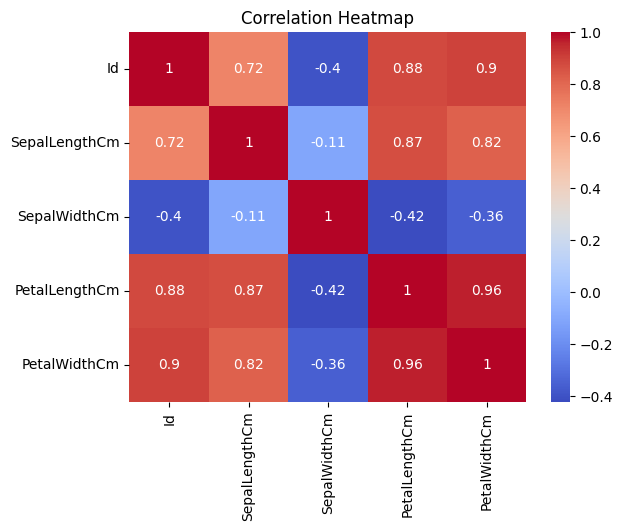

In [15]:
# Correlation Heatmap
numeric_dataset = dataset.select_dtypes(include=[np.number])
sns.heatmap(numeric_dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Prepare feature matrix X and target vector y
target_column = 'Species'
X=dataset.drop(columns=[target_column])
y=dataset[target_column]

# Split into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (120, 5)
X_test shape: (30, 5)
y_train shape: (120,)
y_test shape: (30,)


In [17]:
# Train using Logistic Regression model
lor = LogisticRegression(max_iter=10)
lor.fit(X_train, y_train)
# Make predictions
y_pred = lor.predict(X_test)
print("Predictions:", y_pred)
print(y_train)


Predictions: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa']
22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: Species, Length: 120, dtype: object


C:\Users\mail2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)
roc_auc = roc_auc_score(y_test, lor.predict_proba(X_test), multi_class='ovr')
print("ROC AUC Score:", roc_auc)
# Detailed classification report and confusion matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.9333333333333333
Precision: 0.9444444444444445
Recall: 0.9333333333333333
F1 Score: 0.9321969696969696
ROC AUC Score: 0.9858906525573192
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       1.00      0.78      0.88         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 2  7  0]
 [ 0  0 11]]


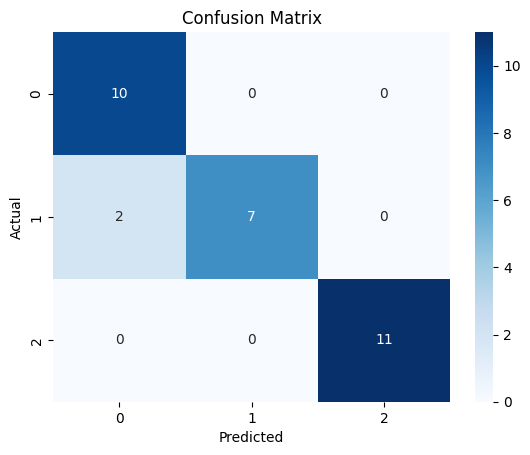

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
# Hyperparameter Tuning - Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lor, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')



Cross-validation scores: [0.75       0.79166667 0.875      0.75       0.79166667]
Mean cross-validation score: 0.7916666666666666


In [21]:
# Make predictions - Before Hyperparameter
y_pred = lor.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
Precision: 0.9444444444444445
Recall: 0.9333333333333333
F1 Score: 0.9321969696969696
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       1.00      0.78      0.88         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [22]:
# Hyperparameter Tuning using GridSearchCV - Fitting 3 folds for each of 72 candidates, totalling 216 fits
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}
grid_search = GridSearchCV(LogisticRegression(max_iter=100), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Model Precision:", precision_score(y_test, y_pred_tuned, average='weighted'))
print("Tuned Model Recall:", recall_score(y_test, y_pred_tuned, average='weighted'))
print("Tuned Model F1 Score:", f1_score(y_test, y_pred_tuned, average='weighted'))
print("Tuned Model Classification Report:\n", classification_report(y_test, y_pred_tuned))

Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Model Accuracy: 1.0
Tuned Model Precision: 1.0
Tuned Model Recall: 1.0
Tuned Model F1 Score: 1.0
Tuned Model Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [23]:
# Make predictions
y_pred = lor.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.9333333333333333
Precision: 0.9444444444444445
Recall: 0.9333333333333333
F1 Score: 0.9321969696969696
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       1.00      0.78      0.88         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [24]:
# Download the updated CSV file
dataset.to_csv("Iris_Updated.csv", index=False)


In [25]:
# Feature Scaling is not required as the dataset does not contain large numeric ranges
# Pickle the model for future use
import pickle
with open('logistic_regression_iris_model.pkl', 'wb') as file:
    pickle.dump(lor, file)


In [26]:
# Load the model from the pickle file and make a sample prediction
with open('logistic_regression_iris_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Predict the loaded model
loaded_model=loaded_model.predict([[991,6.4,2.6,3.5,1.5]])
print("Sample Prediction:", loaded_model)

Sample Prediction: ['Iris-virginica']
